# Contrastive Learning for Bot vs. Human Traffic Detection — Results Report

This notebook consolidates the **leakage-free** evaluation of two contrastive
approaches against supervised and unsupervised baselines, an **ablation study**
auditing potential shortcuts, and a **label-noise audit** based on Confident
Learning. All tables and figures are export-ready for the article.

**Protocol.** Stratified 70/30 train/test split. TF-IDF, Truncated SVD and the
z-score scaler are fitted **only on the training split** and applied to the test
split — preventing the leakage that inflated the original Silhouette-based
evaluation. Deep models run on three seeds (42, 7, 123); we report mean ±
standard deviation on the held-out test set.

**Labels.** Ground truth is the `decision` field of a pre-existing detection
system — i.e., the task is to *imitate that system*, and the labels are
"mostly correct" rather than guaranteed. The final section quantifies how much
noise that assumption introduces.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Article-grade figure style
mpl.rcParams['font.family']   = 'serif'
mpl.rcParams['font.serif']    = ['Times New Roman', 'DejaVu Serif']
mpl.rcParams['font.size']     = 11
mpl.rcParams['axes.titlesize']= 13
mpl.rcParams['axes.labelsize']= 11
mpl.rcParams['figure.dpi']    = 120        # screen; saved figures use dpi=300

SOFT_BLUE, SOFT_RED, SOFT_GREEN, SOFT_ORANGE = '#6A8CAF', '#D87070', '#7FB07F', '#E0A458'

with open('../experiments/results.json') as f:
    R = json.load(f)
MAIN, ABL = R['main'], R['ablation']
print('Loaded results for methods:', list(MAIN.keys()))

Loaded results for methods: ['raw_kmeans', 'pca_kmeans', 'logreg_raw', 'rf_raw', 'triplet_probe', 'cc_cluster', 'cc_probe']


## 1. Benchmark — Supervised Detection (held-out test)

A supervised reference establishes the achievable ceiling. `LogReg` and
`RandomForest` are trained directly on the 68-dimensional engineered features;
`Triplet + probe` and `CC repr + probe` train a logistic-regression probe on top
of the learned contrastive embeddings.

In [2]:
def m2row(d, keys): return {k.upper(): f"{d[k]['mean']:.3f} ± {d[k]['std']:.3f}" for k in keys}
sup_keys = ['f1', 'auc', 'acc']
sup_tbl = pd.DataFrame({
    'Logistic Regression (raw)':    m2row(MAIN['logreg_raw'], sup_keys),
    'Random Forest (raw)':          m2row(MAIN['rf_raw'], sup_keys),
    'Triplet (supervised) + probe': m2row(MAIN['triplet_probe'], sup_keys),
    'Contrastive Clust. repr + probe': m2row(MAIN['cc_probe'], sup_keys),
}).T
sup_tbl.index.name = 'Method'
sup_tbl

,F1,AUC,ACC
Method,,,
Logistic Regression (raw),0.880 ± 0.002,0.961 ± 0.001,0.884 ± 0.002
Random Forest (raw),0.909 ± 0.001,0.977 ± 0.000,0.912 ± 0.001
Triplet (supervised) + probe,0.891 ± 0.004,0.940 ± 0.003,0.892 ± 0.005
Contrastive Clust. repr + probe,0.767 ± 0.033,0.859 ± 0.024,0.770 ± 0.039


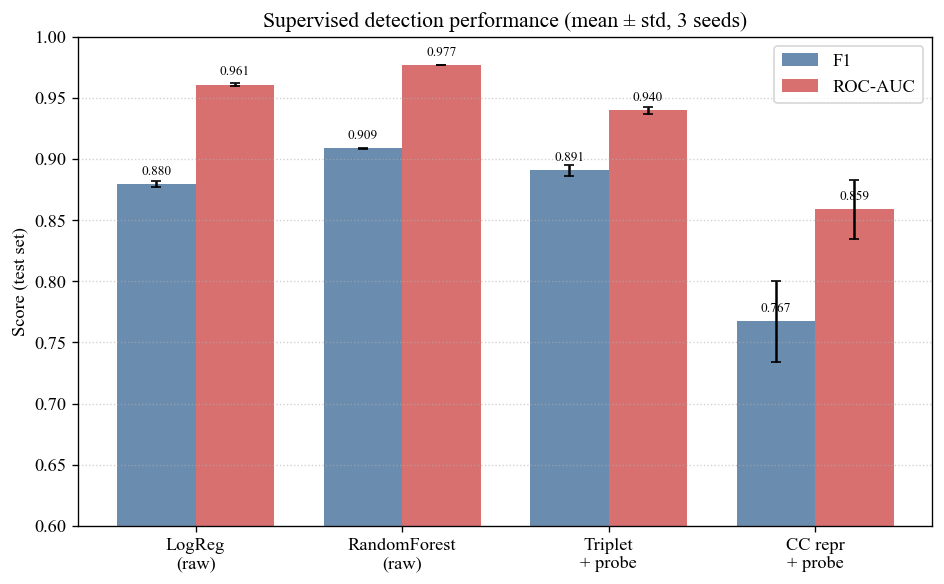

In [3]:
# Figure 1 — supervised F1 / AUC
methods = ['logreg_raw', 'rf_raw', 'triplet_probe', 'cc_probe']
labels  = ['LogReg\n(raw)', 'RandomForest\n(raw)', 'Triplet\n+ probe', 'CC repr\n+ probe']
f1  = [MAIN[m]['f1']['mean']  for m in methods]
f1e = [MAIN[m]['f1']['std']   for m in methods]
auc = [MAIN[m]['auc']['mean'] for m in methods]
auce= [MAIN[m]['auc']['std']  for m in methods]

x = np.arange(len(methods)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, f1,  w, yerr=f1e,  capsize=3, color=SOFT_BLUE, label='F1')
ax.bar(x + w/2, auc, w, yerr=auce, capsize=3, color=SOFT_RED,  label='ROC-AUC')
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylim(0.6, 1.0); ax.set_ylabel('Score (test set)')
ax.set_title('Supervised detection performance (mean ± std, 3 seeds)')
ax.legend(); ax.grid(axis='y', linestyle=':', alpha=0.6)
for xi, v in zip(x - w/2, f1):  ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
for xi, v in zip(x + w/2, auc): ax.text(xi, v+0.008, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout(); plt.savefig('fig1_supervised.pdf', dpi=300, bbox_inches='tight'); plt.show()

**Reading.** The Random Forest on raw features is the strongest model
(F1 = 0.909, AUC = 0.977). The supervised contrastive embedding (Triplet) only
*matches* logistic regression and stays **below** the Random Forest — i.e.,
contrastive learning does not add value over a simple classifier when labels are
abundant. The unsupervised contrastive representation (CC) is clearly the
weakest probe (F1 = 0.767), indicating its generic tabular augmentations
**degrade** the representation.

## 2. Benchmark — Unsupervised Clustering (held-out test)

Clustering quality is measured against the true labels with the
**Adjusted Rand Index (ARI)**, **Normalized Mutual Information (NMI)** and
**clustering accuracy** (Hungarian-matched). Silhouette is deliberately *not*
used as a headline metric — it only measures geometric cohesion and is circular
when the encoder was trained on the labels themselves.

In [4]:
clu_keys = ['ari', 'nmi', 'cluster_acc']
clu_tbl = pd.DataFrame({
    'Raw features + KMeans':       m2row(MAIN['raw_kmeans'], clu_keys),
    'PCA(32) + KMeans':            m2row(MAIN['pca_kmeans'], clu_keys),
    'Contrastive Clustering (CC)': m2row(MAIN['cc_cluster'], clu_keys),
}).T
clu_tbl.index.name = 'Method'
clu_tbl

,ARI,NMI,CLUSTER_ACC
Method,,,
Raw features + KMeans,0.171 ± 0.005,0.284 ± 0.004,0.707 ± 0.003
PCA(32) + KMeans,0.173 ± 0.004,0.285 ± 0.004,0.708 ± 0.003
Contrastive Clustering (CC),0.053 ± 0.048,0.039 ± 0.035,0.596 ± 0.063


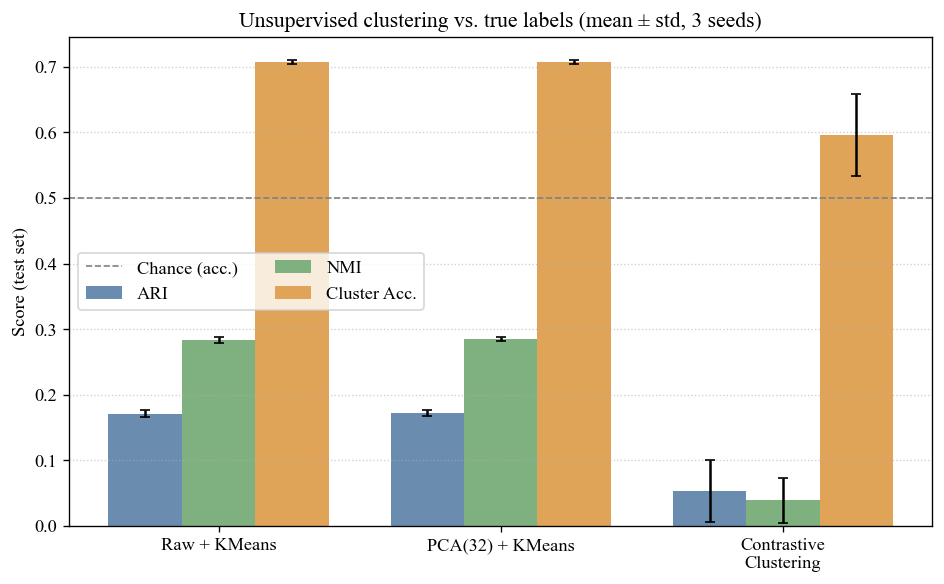

In [5]:
# Figure 2 — unsupervised clustering metrics
cmethods = ['raw_kmeans', 'pca_kmeans', 'cc_cluster']
clabels  = ['Raw + KMeans', 'PCA(32) + KMeans', 'Contrastive\nClustering']
metrics  = ['ari', 'nmi', 'cluster_acc']
mlabels  = ['ARI', 'NMI', 'Cluster Acc.']
colors   = [SOFT_BLUE, SOFT_GREEN, SOFT_ORANGE]

x = np.arange(len(cmethods)); w = 0.26
fig, ax = plt.subplots(figsize=(8, 5))
for j, (met, ml, col) in enumerate(zip(metrics, mlabels, colors)):
    vals = [MAIN[m][met]['mean'] for m in cmethods]
    errs = [MAIN[m][met]['std']  for m in cmethods]
    ax.bar(x + (j-1)*w, vals, w, yerr=errs, capsize=3, color=col, label=ml)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Chance (acc.)')
ax.set_xticks(x); ax.set_xticklabels(clabels)
ax.set_ylabel('Score (test set)')
ax.set_title('Unsupervised clustering vs. true labels (mean ± std, 3 seeds)')
ax.legend(ncol=2); ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout(); plt.savefig('fig2_unsupervised.pdf', dpi=300, bbox_inches='tight'); plt.show()

**Reading.** Plain KMeans on the raw features recovers the structure better
(accuracy = 0.707) than the dedicated Contrastive Clustering model
(0.596 ± 0.063). CC is both **worse than the simplest baseline** and **unstable**
across seeds (note the large error bar and near-zero ARI) — a direct consequence
of augmenting in the compressed SVD space, where masking and Gaussian noise do
not correspond to any plausible traffic variation.

## 3. Ablation — Auditing Shortcuts and Collection Artifacts

A central validity concern: is the model learning *bot behaviour* or merely a
*collection artifact*? We re-run each method under four feature configurations:

- **full** — TF-IDF/SVD of header text + 4 manual size/count features;
- **no_manual** — header text only (removes crude length shortcuts);
- **canonical** — header keys sorted and re-serialized (removes key-order /
  whitespace artifacts);
- **canon_no_manual** — both controls combined.

In [6]:
def abl_row(cfg):
    r = ABL[cfg]
    return {
        'RF — F1':        f"{r['rf_raw']['f1']:.3f}",
        'RF — AUC':       f"{r['rf_raw']['auc']:.3f}",
        'Triplet — F1':   f"{r['triplet_probe']['f1']:.3f}",
        'CC — cluster acc': f"{r['cc_cluster']['cluster_acc']:.3f}",
        'CC — ARI':       f"{r['cc_cluster']['ari']:.3f}",
    }
abl_tbl = pd.DataFrame({
    'full': abl_row('full'),
    'no_manual': abl_row('no_manual'),
    'canonical': abl_row('canonical'),
    'canon_no_manual': abl_row('canon_no_manual'),
}).T
abl_tbl.index.name = 'Feature configuration'
abl_tbl

,RF — F1,RF — AUC,Triplet — F1,CC — cluster acc,CC — ARI
Feature configuration,,,,,
full,0.908,0.977,0.886,0.670,0.116
no_manual,0.885,0.964,0.887,0.502,-0.000
canonical,0.907,0.976,0.892,0.605,0.044
canon_no_manual,0.885,0.965,0.883,0.506,-0.000


**Reading.**
- **Canonicalizing the headers barely moves anything** (RF F1 0.908 → 0.907) —
  the signal is *not* an artifact of key ordering or serialization; it lives in
  the header *content* (User-Agent strings, etc.).
- **Removing the manual length features costs the Random Forest little**
  (0.908 → 0.885) — the discriminative signal is carried by the text n-grams,
  not by a trivial "bots send shorter headers" shortcut.
- **Contrastive Clustering collapses to a single cluster** without the manual
  features (accuracy → 0.50, ARI → 0.00): it was relying entirely on those four
  numbers. This is a serious robustness weakness, not a minor caveat.

## 4. Label-Noise Audit — Confident Learning

Because the labels are "mostly correct" rather than guaranteed, we quantify the
noise with **Confident Learning** (Northcutt et al., 2021): out-of-fold
predicted probabilities from a strong classifier (5-fold Random Forest) plus
per-class confidence thresholds flag samples whose model-implied class
*confidently* disagrees with the given label.

In [7]:
A = np.load('../experiments/audit_arrays.npz')
y, proba, flags, susp, hl, thr = A['y'], A['proba'], A['flags'], A['susp'], A['hl'], A['thr']

n = len(y)
rate = 100 * flags.mean()
n_bot   = (flags & (y == 1)).sum()
n_human = (flags & (y == 0)).sum()
print(f"Per-class self-confidence thresholds : human={thr[0]:.3f}, bot={thr[1]:.3f}")
print(f"Samples flagged as likely mislabeled : {flags.sum()} / {n}  ({rate:.2f}%)")
print(f"  - labeled 'bots'   but model-confident human : {n_bot}")
print(f"  - labeled 'unsafe' but model-confident bot   : {n_human}")

Per-class self-confidence thresholds : human=0.844, bot=0.848
Samples flagged as likely mislabeled : 98 / 20000  (0.49%)
  - labeled 'bots'   but model-confident human : 98
  - labeled 'unsafe' but model-confident bot   : 0


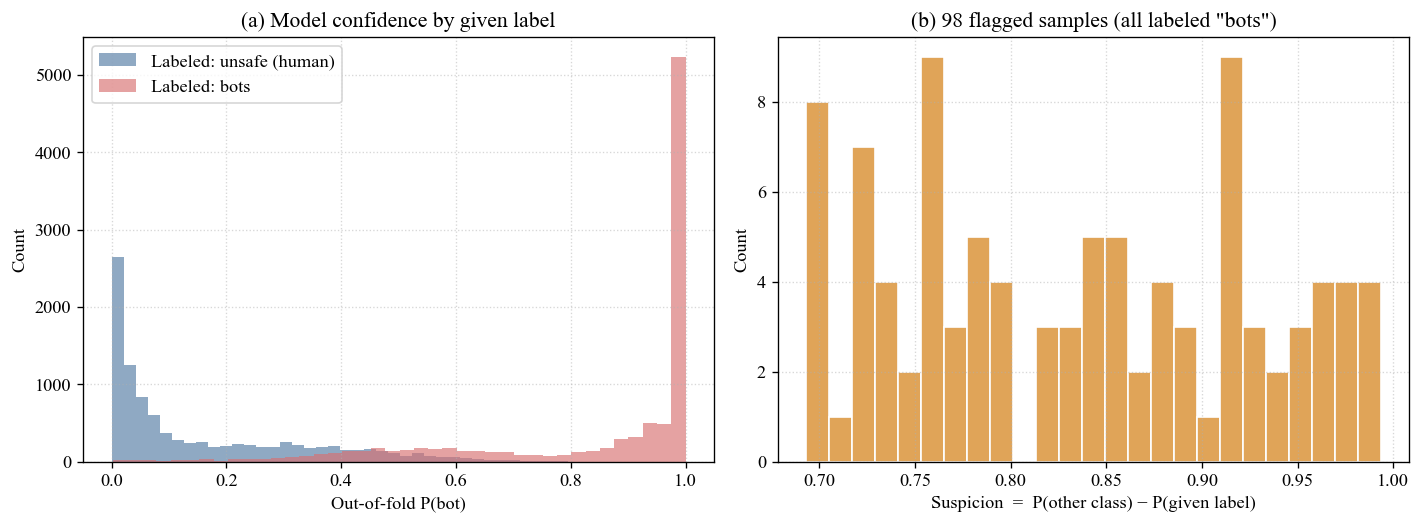

In [8]:
# Figure 3 — out-of-fold confidence distribution and flagged-sample suspicion
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) OOF probability of being a bot, by true label
axes[0].hist(proba[y == 0, 1], bins=40, color=SOFT_BLUE, alpha=0.75, label='Labeled: unsafe (human)')
axes[0].hist(proba[y == 1, 1], bins=40, color=SOFT_RED,  alpha=0.65, label='Labeled: bots')
axes[0].set_xlabel('Out-of-fold P(bot)'); axes[0].set_ylabel('Count')
axes[0].set_title('(a) Model confidence by given label')
axes[0].legend(); axes[0].grid(linestyle=':', alpha=0.5)

# (b) suspicion of the flagged samples
axes[1].hist(susp[flags], bins=25, color=SOFT_ORANGE, edgecolor='white')
axes[1].set_xlabel('Suspicion  =  P(other class) − P(given label)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'(b) {flags.sum()} flagged samples (all labeled "bots")')
axes[1].grid(linestyle=':', alpha=0.5)
plt.tight_layout(); plt.savefig('fig3_noise_audit.pdf', dpi=300, bbox_inches='tight'); plt.show()

In [9]:
# Candidate gold-set: the most suspicious samples, exported for hand-verification
suspects = pd.read_csv('../experiments/gold_set_suspects.csv')
print(f"Exported {len(suspects)} suspects to experiments/gold_set_suspects.csv")
suspects.head(10)

Exported 98 suspects to experiments/gold_set_suspects.csv


,index,given_label,P(human),P(bot),suspicion,user_agent,has_template
0,14897,bots,0.997,0.003,0.993,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
1,15006,bots,0.997,0.003,0.993,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
2,15017,bots,0.993,0.007,0.987,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
3,14822,bots,0.993,0.007,0.987,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
4,14759,bots,0.990,0.010,0.980,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
5,14750,bots,0.987,0.013,0.973,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
6,14783,bots,0.987,0.013,0.973,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
7,14851,bots,0.987,0.013,0.973,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
8,14780,bots,0.983,0.017,0.967,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False
9,14712,bots,0.983,0.017,0.967,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,False


**Reading.** Confident Learning flags only **0.49 % of the data (98 samples),
and every one is in the `bots` class** — there is no detectable noise among the
`unsafe` (human) labels. The flagged samples are requests labeled *bot* that
carry ordinary browser User-Agents (Chrome/Windows) and no template markers, so
the model reads them as human. These are exactly the cases to hand-verify for a
**gold test set**: they are either genuine label errors or sophisticated bots
that are behaviourally indistinguishable from humans.

*Caveat.* Confident Learning only detects noise the model disagrees with; if the
upstream labeling system and our classifier share the same blind spots, the true
noise rate is underestimated. The 0.49 % figure is therefore a **lower bound**.

## 5. High-Precision Heuristic Anchors — Cross-Check

Independently of the model, two near-certain bot signals are available:
unsubstituted `{{...}}` request templates and known crawler User-Agents
(e.g., `facebookexternalhit`). We use them only to *cross-check* the labels — not
as model features.

In [10]:
anchor_bot = (hl == 1)
coverage   = 100 * (hl != -1).mean()
contra     = int((anchor_bot & (y == 0)).sum())      # anchor says bot, label says human
agree      = 100 * (anchor_bot & (y == 1)).sum() / anchor_bot.sum()
print(f"Heuristic anchors fire on        : {coverage:.1f}% of all samples")
print(f"Anchor=bot but label=unsafe      : {contra}  (contradictions)")
print(f"Agreement on anchored samples    : {agree:.1f}% labeled 'bots'")

Heuristic anchors fire on        : 35.6% of all samples
Anchor=bot but label=unsafe      : 0  (contradictions)
Agreement on anchored samples    : 100.0% labeled 'bots'


**Reading.** The heuristic anchors fire on **35.6 %** of the corpus and are
in **100 % agreement** with the given labels — **zero contradictions**. This is
strong independent evidence that the `bots` labels are reliable where any signal
exists, and it corroborates the low noise rate from Section 4. The residual
uncertainty is concentrated in the "quiet" bots that leave no obvious fingerprint
— precisely the 98 samples flagged in Section 4.

## 6. Label-Efficiency Curve — Does Contrastive Win With Few Labels?

The standard argument for self-supervised / contrastive learning is the
**low-label regime**: an encoder pretrained without labels should beat a model
trained from scratch when only a few labels are available. We test this directly.
For label fractions of 1 %, 5 %, 10 %, 25 %, 50 % and 100 % of the training set we
compare five methods, all evaluated on the same held-out test set:

- `logreg_raw`, `rf_raw` — supervised baselines on raw features;
- `mlp_scratch` — supervised neural net (same backbone) trained from scratch;
- `ssl_probe` — **self-supervised** contrastive pretraining (NT-Xent, no labels)
  on all training data, frozen backbone, logistic probe on the labeled fraction;
- `triplet_probe` — supervised contrastive (Triplet) on the labeled fraction.

In [11]:
with open('../experiments/label_efficiency.json') as f:
    LE = json.load(f)
fracs = LE['logreg_raw']['frac']
le_names = {'logreg_raw':'LogReg (raw)', 'rf_raw':'RandomForest (raw)',
            'mlp_scratch':'MLP (from scratch)', 'ssl_probe':'SSL pretrain + probe',
            'triplet_probe':'Triplet + probe'}
le_tbl = pd.DataFrame(
    {le_names[m]: [f"{v:.3f}" for v in LE[m]['f1_mean']] for m in le_names},
    index=[f"{int(f*100)}%" for f in fracs],
)
le_tbl.index.name = 'Labeled fraction'
le_tbl  # F1 (mean over 3 seeds)

,LogReg (raw),RandomForest (raw),MLP (from scratch),SSL pretrain + probe,Triplet + probe
Labeled fraction,,,,,
1%,0.812,0.835,0.804,0.804,0.810
5%,0.854,0.863,0.848,0.823,0.850
10%,0.865,0.876,0.861,0.831,0.857
25%,0.877,0.887,0.868,0.837,0.869
50%,0.878,0.899,0.881,0.841,0.881
100%,0.880,0.909,0.887,0.842,0.891


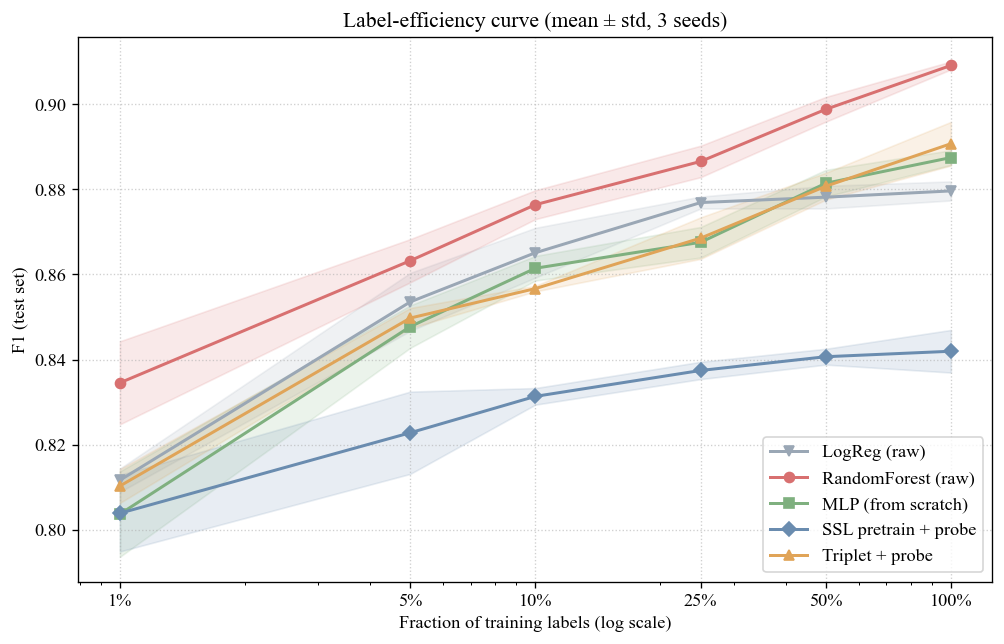

In [12]:
# Figure 4 — label-efficiency curve (F1 vs. fraction of labels)
le_colors = {'logreg_raw':'#9AA7B5', 'rf_raw':SOFT_RED, 'mlp_scratch':SOFT_GREEN,
             'ssl_probe':SOFT_BLUE, 'triplet_probe':SOFT_ORANGE}
le_marker = {'logreg_raw':'v', 'rf_raw':'o', 'mlp_scratch':'s', 'ssl_probe':'D', 'triplet_probe':'^'}

fig, ax = plt.subplots(figsize=(8.5, 5.5))
xs = np.array(fracs) * 100
for m in le_names:
    mean = np.array(LE[m]['f1_mean']); std = np.array(LE[m]['f1_std'])
    ax.plot(xs, mean, marker=le_marker[m], color=le_colors[m], label=le_names[m], linewidth=1.8)
    ax.fill_between(xs, mean - std, mean + std, color=le_colors[m], alpha=0.15)
ax.set_xscale('log')
ax.set_xticks(xs); ax.set_xticklabels([f"{int(x)}%" if x >= 1 else f"{x:g}%" for x in xs])
ax.set_xlabel('Fraction of training labels (log scale)')
ax.set_ylabel('F1 (test set)')
ax.set_title('Label-efficiency curve (mean ± std, 3 seeds)')
ax.legend(loc='lower right'); ax.grid(linestyle=':', alpha=0.6)
plt.tight_layout(); plt.savefig('fig4_label_efficiency.pdf', dpi=300, bbox_inches='tight'); plt.show()

**Reading.** The contrastive hypothesis **does not hold on this task**. The
Random Forest is the best method at *every* label fraction — including the extreme
1 % regime (140 labeled samples), where it reaches F1 = 0.835 versus 0.804 for the
self-supervised probe. Two patterns stand out:

- **The task is "easy".** A mere 1 % of labels already yields F1 ≈ 0.83, because
  the discriminative signal (User-Agent strings, request templates) is shallow and
  strong. There is no representation-learning gap for self-supervision to fill.
- **The SSL probe plateaus early** (0.804 → 0.842 from 1 % to 100 %) while the
  supervised methods keep improving. The generic SVD-space augmentations cap the
  representation quality — the encoder simply cannot encode information its
  augmentations destroy.

This closes the last escape hatch: contrastive learning is not justified here even
under label scarcity.

## 7. Discussion — What These Results Mean for the Paper

**1. Under a correct protocol, contrastive learning does not beat simple
baselines on this task.** With ~14k clean-enough labels, a Random Forest on the
engineered features reaches F1 = 0.909 / AUC = 0.977. Neither the supervised
contrastive embedding (Triplet, F1 = 0.891) nor the unsupervised one (CC,
F1 = 0.767) surpasses it. The original Silhouette score, computed in-sample, gave
a *false* impression of success — once leakage is removed, the advantage
disappears. This is an honest, defensible finding.

**2. The unsupervised contrastive clustering model is fragile.** It
under-performs plain KMeans (0.596 vs. 0.707 accuracy), is unstable across seeds,
and collapses entirely when the four manual features are withheld. The root cause
is the augmentation strategy: masking and Gaussian noise applied in the
SVD-compressed space do not represent semantically valid traffic variation.

**3. The signal is genuine, not an artifact.** The ablation shows results are
robust to header canonicalization and survive the removal of crude length
features — the discriminative information is in the header *content*. This
pre-empts the most likely reviewer objection.

**4. The labels are clean enough to trust — with a measurable caveat.** Confident
Learning flags only 0.49 % of samples (all bots), and high-precision heuristics
agree with 100 % of anchored labels. The dataset is therefore a sound basis for
the study, provided the paper (a) states that labels are an existing system's
*decisions*, not absolute truth, and (b) reports final numbers on a small
hand-verified **gold test set** built from the 98 flagged cases — removing the
noise ceiling that otherwise caps every model near F1 ≈ 0.91.

**5. Contrastive learning does not win even under label scarcity (Section 6).**
The label-efficiency curve tested the strongest remaining argument for
self-supervision and refuted it: the Random Forest leads at every fraction, and
even at 1 % of labels it beats the self-supervised probe (0.835 vs. 0.804). The
self-supervised representation plateaus at F1 ≈ 0.84 because the SVD-space
augmentations cap what the encoder can learn, and the task is shallow enough that
a handful of labels already saturates performance. The single remaining lever is
**text-level augmentation** (header dropout, value perturbation) applied *before*
the SVD projection — the only change with a plausible chance of lifting the
contrastive ceiling; everything else points to simple supervised models being the
correct choice for this problem.

**6. Recommended framing.** Present this as a rigorous, honest evaluation:
*"For HTTP-header bot detection, leakage-free experiments show that simple
supervised classifiers match or exceed both supervised and self-supervised
contrastive learning across the full label-budget spectrum; the discriminative
signal is shallow and content-driven, the labels are clean, and generic tabular
augmentations limit contrastive representation quality."* This is a publishable
negative/cautionary result, fully supported by the ablation, noise audit and
label-efficiency analyses.

### Summary table

| Question | Evidence | Verdict |
|---|---|---|
| Does contrastive beat baselines (full labels)? | RF 0.909 F1 vs. Triplet 0.891, CC 0.767 | No |
| Does contrastive win with few labels? | RF 0.835 vs. SSL 0.804 at 1 % | No — RF leads everywhere |
| Is unsupervised CC reliable? | 0.596 ± 0.063 acc, collapses w/o manual feats | No — fragile |
| Is the signal a collection artifact? | Canonicalization changes nothing | No — content-driven |
| Are the labels trustworthy? | 0.49 % flagged, 100 % heuristic agreement | Yes — low, asymmetric noise |
| Remaining lever for contrastive? | SSL plateaus at 0.84 w/ SVD-space noise | Text-level augmentation only |